# 04 — Evaluation

Reload the saved model and turn scores into campaign decisions: test metrics, calibration, lift/value, and a cost-aware threshold.


In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.calibration import calibration_curve


## Load test data and final model


In [2]:
# Local path from notebooks/. On Colab, point this at your project data/processed folder.
PROCESSED_DIR = Path("../data/processed")

X_test = np.load(PROCESSED_DIR / "X_test.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")
feature_names = joblib.load(PROCESSED_DIR / "feature_names.joblib")

model = joblib.load(PROCESSED_DIR / "final_model.joblib")
meta = joblib.load(PROCESSED_DIR / "final_model_meta.joblib")
f1_threshold = float(meta["threshold"])

test_prob = model.predict_proba(X_test)[:, 1]

print("Test:", X_test.shape, y_test.shape)
print("Features:", len(feature_names))
print("F1 threshold from modeling:", round(f1_threshold, 3))
print("scale_pos_weight:", round(meta.get("scale_pos_weight", float("nan")), 2))
print("Best params:", meta["best_params"])


Test: (9043, 56) (9043,)
Features: 56
F1 threshold from modeling: 0.629
scale_pos_weight: 7.55
Best params: {'subsample': 0.6, 'reg_lambda': 10, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


## Test metrics (F1 threshold from modeling)


In [3]:
def metrics_at_threshold(y_true, prob, threshold, name):
    pred = (prob >= threshold).astype(int)
    return {
        "Rule": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, prob),
        "PR-AUC": average_precision_score(y_true, prob),
        "Brier": brier_score_loss(y_true, prob),
    }

f1_pred = (test_prob >= f1_threshold).astype(int)
base_results = metrics_at_threshold(y_test, test_prob, f1_threshold, "F1 threshold")
pd.DataFrame([base_results]).round(3)


,Rule,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,F1 threshold,0.629,0.873,0.463,0.535,0.496,0.807,0.468,0.153


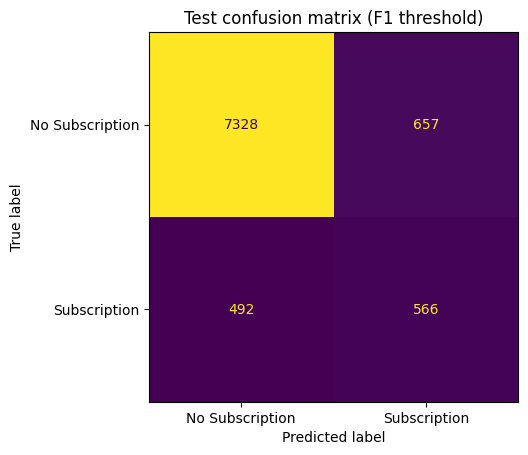

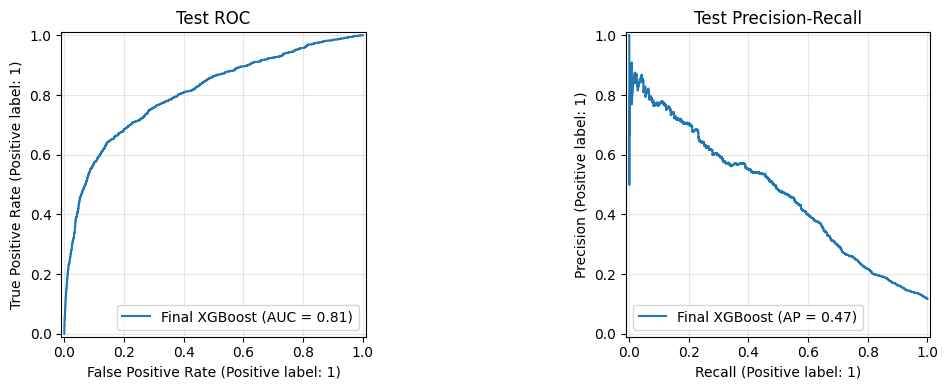

In [4]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    f1_pred,
    display_labels=["No Subscription", "Subscription"],
    colorbar=False,
)
plt.title("Test confusion matrix (F1 threshold)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, test_prob, name="Final XGBoost", ax=axes[0])
axes[0].set_title("Test ROC")
axes[0].grid(alpha=0.3)
PrecisionRecallDisplay.from_predictions(y_test, test_prob, name="Final XGBoost", ax=axes[1])
axes[1].set_title("Test Precision-Recall")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Probability calibration

If predicted probabilities are well calibrated, a score of 0.3 really means ~30% chance of subscription. That matters for expected-value decisions.


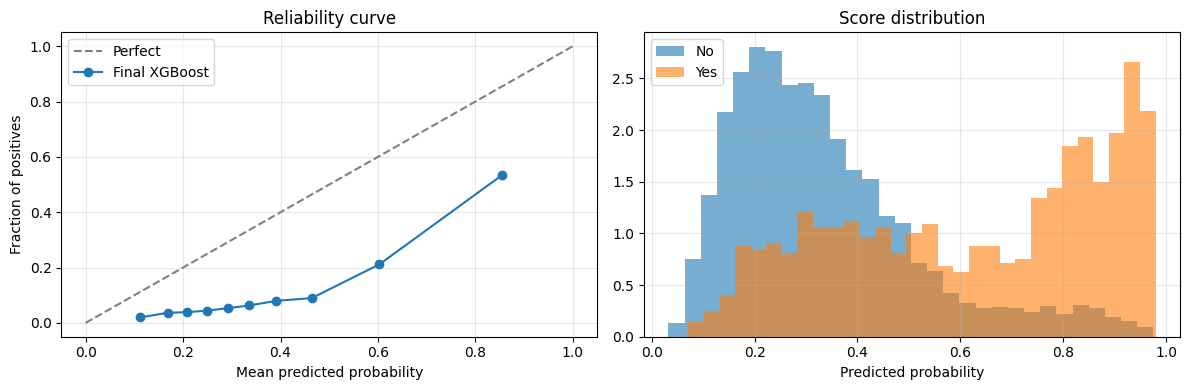

Brier score (lower is better): 0.1525


In [5]:
prob_true, prob_pred = calibration_curve(y_test, test_prob, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
axes[0].plot(prob_pred, prob_true, marker="o", label="Final XGBoost")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Fraction of positives")
axes[0].set_title("Reliability curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(test_prob[y_test == 0], bins=30, alpha=0.6, label="No", density=True)
axes[1].hist(test_prob[y_test == 1], bins=30, alpha=0.6, label="Yes", density=True)
axes[1].set_title("Score distribution")
axes[1].set_xlabel("Predicted probability")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Brier score (lower is better):", round(brier_score_loss(y_test, test_prob), 4))


## Lift and campaign value

Sort clients by predicted probability and pretend we only call the top X%. Lift shows how much better that is than random calling.


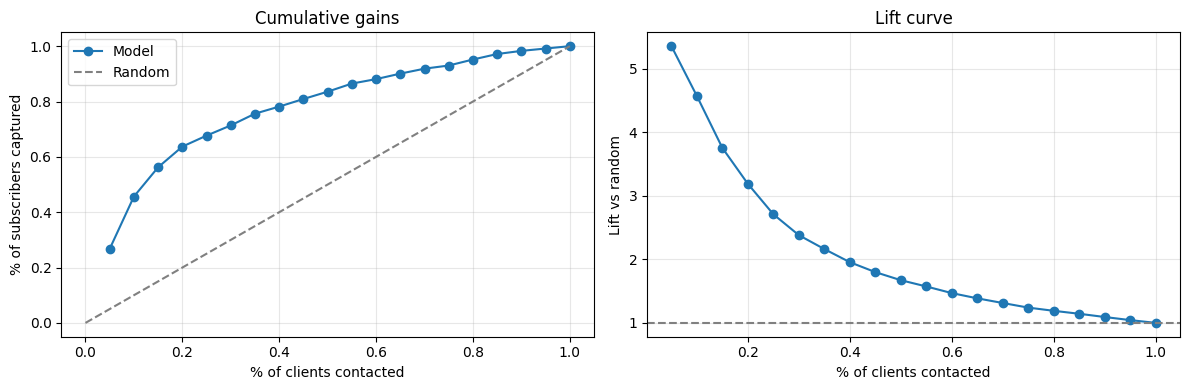

,pct_contacted,pct_positives_captured,precision_in_slice,lift
3,20.0,63.7,0.373,3.186
7,40.0,78.2,0.229,1.954
9,50.0,83.6,0.196,1.671
13,70.0,91.9,0.154,1.312
19,100.0,100.0,0.117,1.000


In [6]:
def cumulative_gains(y_true, prob, n_bins=20):
    order = np.argsort(-prob)
    y_sorted = y_true[order]
    n = len(y_sorted)
    total_pos = y_sorted.sum()
    cuts = np.linspace(0, n, n_bins + 1, dtype=int)
    rows = []
    for i in range(1, len(cuts)):
        k = cuts[i]
        contacted = k
        captured = y_sorted[:k].sum()
        rows.append(
            {
                "pct_contacted": contacted / n,
                "pct_positives_captured": captured / total_pos if total_pos else 0,
                "n_contacted": contacted,
                "n_subscribers": int(captured),
                "precision_in_slice": captured / contacted if contacted else 0,
                "lift": (captured / contacted) / (total_pos / n) if contacted and total_pos else 0,
            }
        )
    return pd.DataFrame(rows)

gains = cumulative_gains(y_test, test_prob, n_bins=20)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(gains["pct_contacted"], gains["pct_positives_captured"], marker="o", label="Model")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random")
axes[0].set_xlabel("% of clients contacted")
axes[0].set_ylabel("% of subscribers captured")
axes[0].set_title("Cumulative gains")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(gains["pct_contacted"], gains["lift"], marker="o")
axes[1].axhline(1.0, color="gray", linestyle="--")
axes[1].set_xlabel("% of clients contacted")
axes[1].set_ylabel("Lift vs random")
axes[1].set_title("Lift curve")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Example operating points
show = gains.iloc[[3, 7, 9, 13, 19]][["pct_contacted", "pct_positives_captured", "precision_in_slice", "lift"]].copy()
show["pct_contacted"] = (show["pct_contacted"] * 100).round(1)
show["pct_positives_captured"] = (show["pct_positives_captured"] * 100).round(1)
show.round(3)


## Expected value under a simple call economics model

Assume each call costs `call_cost` and each successful subscription is worth `subscription_value`.  
If we call everyone predicted positive:

expected profit ≈ TP * subscription_value − (TP + FP) * call_cost


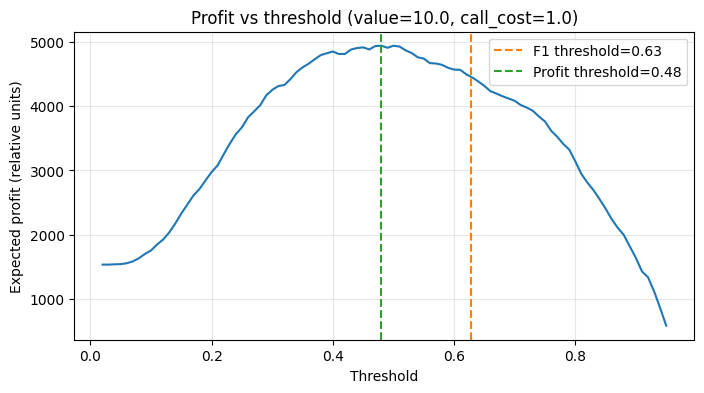

Best profit threshold: 0.48
threshold       0.480
tp            703.000
fp           1391.000
fn            355.000
contacts     2094.000
profit       4936.000
precision       0.336
recall          0.664
Name: 46, dtype: float64


In [7]:
CALL_COST = 1.0
SUBSCRIPTION_VALUE = 10.0  # relative units; swap in real campaign economics later


def profit_at_threshold(y_true, prob, threshold, call_cost=CALL_COST, value=SUBSCRIPTION_VALUE):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    profit = tp * value - (tp + fp) * call_cost
    return {
        "threshold": threshold,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "contacts": int(tp + fp),
        "profit": profit,
        "precision": tp / (tp + fp) if (tp + fp) else 0,
        "recall": tp / (tp + fn) if (tp + fn) else 0,
    }

grid = np.linspace(0.02, 0.95, 94)
profit_rows = [profit_at_threshold(y_test, test_prob, t) for t in grid]
profit_df = pd.DataFrame(profit_rows)
best_profit_row = profit_df.loc[profit_df["profit"].idxmax()]
profit_threshold = float(best_profit_row["threshold"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(profit_df["threshold"], profit_df["profit"])
ax.axvline(f1_threshold, color="C1", linestyle="--", label=f"F1 threshold={f1_threshold:.2f}")
ax.axvline(profit_threshold, color="C2", linestyle="--", label=f"Profit threshold={profit_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Expected profit (relative units)")
ax.set_title(f"Profit vs threshold (value={SUBSCRIPTION_VALUE}, call_cost={CALL_COST})")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print("Best profit threshold:", round(profit_threshold, 3))
print(best_profit_row.round(3))


## Cost-sensitive threshold (FP vs FN costs)

Alternative view: minimize expected misclassification cost  
`cost = FP * cost_fp + FN * cost_fn`  
with example ratio `cost_fn / cost_fp = 5` (missing a subscriber hurts more than an extra call).


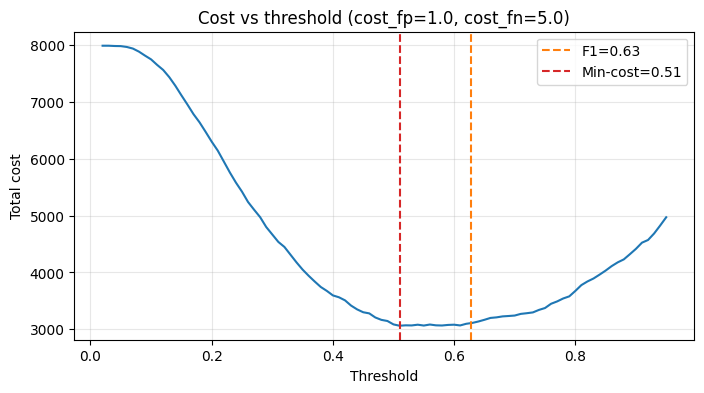

Min-cost threshold: 0.51
threshold       0.51
cost         3063.00
fp           1143.00
fn            384.00
tp            674.00
Name: 49, dtype: float64


,Rule,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,F1 threshold,0.629,0.873,0.463,0.535,0.496,0.807,0.468,0.153
1,Max-profit threshold,0.480,0.807,0.336,0.664,0.446,0.807,0.468,0.153
2,Min-cost threshold,0.510,0.831,0.371,0.637,0.469,0.807,0.468,0.153
3,Default 0.5,0.500,0.825,0.361,0.646,0.463,0.807,0.468,0.153


In [8]:
COST_FP = 1.0
COST_FN = 5.0


def total_cost(y_true, prob, threshold, cost_fp=COST_FP, cost_fn=COST_FN):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return fp * cost_fp + fn * cost_fn, int(fp), int(fn), int(tp)

cost_rows = []
for t in grid:
    cost, fp, fn, tp = total_cost(y_test, test_prob, t)
    cost_rows.append({"threshold": t, "cost": cost, "fp": fp, "fn": fn, "tp": tp})
cost_df = pd.DataFrame(cost_rows)
best_cost_row = cost_df.loc[cost_df["cost"].idxmin()]
cost_threshold = float(best_cost_row["threshold"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost_df["threshold"], cost_df["cost"])
ax.axvline(f1_threshold, color="C1", linestyle="--", label=f"F1={f1_threshold:.2f}")
ax.axvline(cost_threshold, color="C3", linestyle="--", label=f"Min-cost={cost_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Total cost")
ax.set_title(f"Cost vs threshold (cost_fp={COST_FP}, cost_fn={COST_FN})")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print("Min-cost threshold:", round(cost_threshold, 3))
print(best_cost_row.round(3))

compare_rules = pd.DataFrame(
    [
        metrics_at_threshold(y_test, test_prob, f1_threshold, "F1 threshold"),
        metrics_at_threshold(y_test, test_prob, profit_threshold, "Max-profit threshold"),
        metrics_at_threshold(y_test, test_prob, cost_threshold, "Min-cost threshold"),
        metrics_at_threshold(y_test, test_prob, 0.5, "Default 0.5"),
    ]
).round(3)
compare_rules


## Feature importance


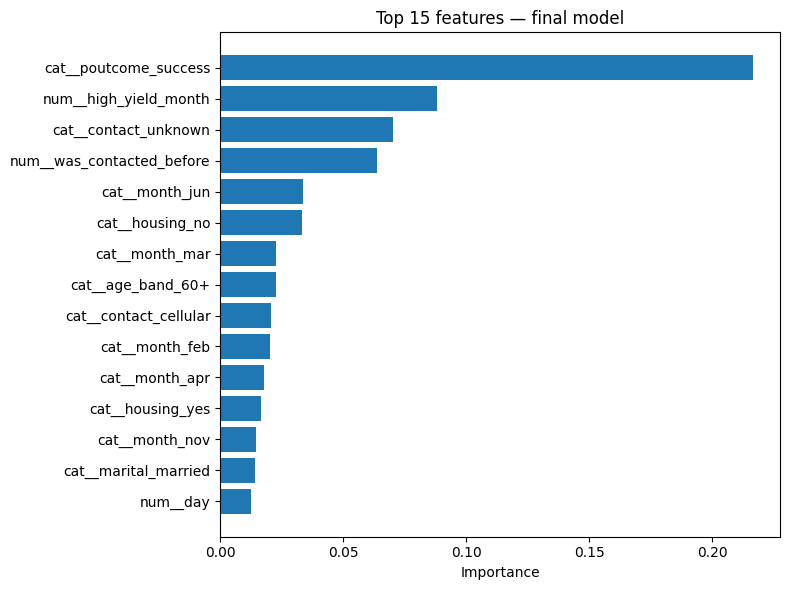

,Feature,Importance
50,cat__poutcome_success,0.2167
7,num__high_yield_month,0.0881
35,cat__contact_unknown,0.0702
6,num__was_contacted_before,0.0639
42,cat__month_jun,0.0336
29,cat__housing_no,0.0331
43,cat__month_mar,0.0229
54,cat__age_band_60+,0.0228
33,cat__contact_cellular,0.0207
39,cat__month_feb,0.0201


In [9]:
importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": model.feature_importances_}
)
top_features = (
    importance_df.sort_values("Importance", ascending=False)
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 15 features — final model")
plt.tight_layout()
plt.show()

top_features.sort_values("Importance", ascending=False).round(4)


## Save test predictions

Write scored test rows for the report / downstream analysis.


In [10]:
pred_f1 = (test_prob >= f1_threshold).astype(int)
pred_profit = (test_prob >= profit_threshold).astype(int)
pred_cost = (test_prob >= cost_threshold).astype(int)

pred_df = pd.DataFrame(
    {
        "y_true": y_test.astype(int),
        "prob": test_prob,
        "pred_f1_threshold": pred_f1,
        "pred_profit_threshold": pred_profit,
        "pred_cost_threshold": pred_cost,
    }
)
out_path = PROCESSED_DIR / "test_predictions.csv"
pred_df.to_csv(out_path, index=False)

joblib.dump(
    {
        **meta,
        "f1_threshold": f1_threshold,
        "profit_threshold": profit_threshold,
        "cost_threshold": cost_threshold,
        "call_cost": CALL_COST,
        "subscription_value": SUBSCRIPTION_VALUE,
        "cost_fp": COST_FP,
        "cost_fn": COST_FN,
    },
    PROCESSED_DIR / "evaluation_meta.joblib",
)
print("Saved", out_path)
print(pred_df.head())


Saved ../data/processed/test_predictions.csv
   y_true      prob  pred_f1_threshold  pred_profit_threshold  \
0       0  0.157292                  0                      0   
1       0  0.213433                  0                      0   
2       0  0.246697                  0                      0   
3       0  0.212504                  0                      0   
4       0  0.421976                  0                      0   

   pred_cost_threshold  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  


## Summary

- Reloaded the held-out test set and saved tuned XGBoost model
- Reported test metrics with the modeling F1 threshold, plus ROC/PR and calibration checks
- Compared lift/gains and expected-value / cost-sensitive thresholds for campaign decisions
- Saved `test_predictions.csv` and evaluation metadata
